# Synthetic experiments for NEMS (principal-alignment benchmark)

This notebook reproduces the synthetic benchmark used to compare **NEMS** against **vanilla marginal interaction testing** (raw and Bonferroni-adjusted), using IoU against the two principally aligned neurons as ground truth.

- DGP: \(T\in\{0,1\}\), two latent modifiers \(U\in\mathbb{R}^2\), \(m=500\) embedding neurons \(Z = AU + \varepsilon\)
- Outcomes: continuous Gaussian (default; switchable to binary), with linear or quadratic treatment-effect heterogeneity
- Evaluation: 10 seeds, IoU vs truth \(\{j_1^\star, j_2^\star\}\)


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data import make_loading_matrix, generate_synthetic_rct
from nems import evaluate_methods_on_dataset

# Optional: nicer display in notebooks
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)


In [2]:
# -----------------------------
# Global configuration
# -----------------------------
ALPHA = 0.05
M = 500
SEEDS = list(range(50))
NEMS_MAX_STEPS = 20   # enough to reveal over-selection while keeping runtime manageable

# DGP family choices
INTERACTION_FORM = "linear"      # "linear" or "quadratic"
OUTCOME_FAMILY = "gaussian"      # "gaussian" (recommended default) or "binary"

# If True, resample A per seed instead of fixing it across all runs
RESAMPLE_A = False
# If True, offset seeds across effect/sample size grid points
OFFSET_SEED_WITH_GRID = False

# Strong principal-alignment matrix A (fixed across all runs for comparability)
A, PRINCIPAL_IDX = make_loading_matrix(
    m=M,
    seed=2026,
    principal_loading=3.5,
    leakage_scale=0.18,
    delta=1.4,
    cross_loading_principal=0.05,
)

# Common DGP kwargs (you can tweak these)
DGP_KWARGS = dict(
    m=M,
    interaction_form=INTERACTION_FORM,
    outcome_family=OUTCOME_FAMILY,
    z_noise_sd=0.8,
    y_noise_sd=1.0,
    standardize_z=True,
)
if not RESAMPLE_A:
    DGP_KWARGS["fixed_A"] = A
    DGP_KWARGS["fixed_principal_idx"] = PRINCIPAL_IDX

PRINCIPAL_IDX


(0, 1)

In [3]:
def run_one(seed, n, effect_scale, alpha=ALPHA, nems_max_steps=NEMS_MAX_STEPS, **dgp_kwargs):
    d = generate_synthetic_rct(n=n, effect_scale=effect_scale, seed=seed, **dgp_kwargs)
    metrics = evaluate_methods_on_dataset(
        d.Y, d.T, d.Z,
        truth=d.principal_idx,
        alpha=alpha,
        nems_max_steps=nems_max_steps,
    )
    rows = []
    for method, vals in metrics.items():
        row = dict(seed=seed, n=n, effect_scale=effect_scale, method=method)
        row.update(vals)
        rows.append(row)
    return rows


def _seed_with_offset(base_seed: int, offset: int) -> int:
    return int(base_seed) + int(offset) * 1000003


def run_sweep_effect(effect_grid, n_fixed, seeds=SEEDS, **dgp_kwargs):
    rows = []
    for es_idx, es in enumerate(effect_grid):
        for seed in seeds:
            seed_use = _seed_with_offset(seed, es_idx) if OFFSET_SEED_WITH_GRID else seed
            rows.extend(run_one(seed=seed_use, n=n_fixed, effect_scale=es, **dgp_kwargs))
    return pd.DataFrame(rows)


def run_sweep_n(n_grid, effect_fixed, seeds=SEEDS, **dgp_kwargs):
    rows = []
    for n_idx, n in enumerate(n_grid):
        for seed in seeds:
            seed_use = _seed_with_offset(seed, n_idx) if OFFSET_SEED_WITH_GRID else seed
            rows.extend(run_one(seed=seed_use, n=int(n), effect_scale=effect_fixed, **dgp_kwargs))
    return pd.DataFrame(rows)


def summarize_curve(df, xcol="effect_scale", ycol="iou"):
    g = (df.groupby([xcol, "method"])[ycol]
           .agg(["mean", "std", "count"])
           .reset_index())
    g["se"] = g["std"] / np.sqrt(g["count"].clip(lower=1))
    return g


def plot_iou_curve(summary_df, xcol, metric_name, x_label, out_path=None):
    plt.figure(figsize=(4, 3))
    order = [
        ("Marginal", "Marginal"),
        ("Marginal (Bonferroni)", "Marginal (Bonf.)"),
        ("NEMS", "NEMS"),
    ]
    colors = {
        "Marginal": "#a6cee3",
        "Marginal (Bonferroni)": "#b2df8a",
        "NEMS": "#fdbf6f",
    }
    z = 1.96
    for method, label in order:
        if method not in summary_df["method"].unique():
            continue
        sub = summary_df[summary_df["method"] == method].sort_values(xcol)
        x = sub[xcol].to_numpy()
        mean = sub["mean"].to_numpy()
        se = sub["se"].to_numpy()
        lower = mean - z * se
        upper = mean + z * se
        plt.plot(
            x,
            mean,
            marker="o",
            label=label,
            color=colors.get(method, "#999999"),
        )
        plt.fill_between(x, lower, upper, color=colors.get(method, "#999999"), alpha=0.25)
    plt.ylim(-0.02, 1.02)
    plt.xlabel(x_label)
    plt.ylabel(metric_name)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if out_path:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        plt.savefig(out_path, bbox_inches="tight")


## Sweep 1 — effect size vs IoU

In [4]:
EFFECT_GRID = np.linspace(0.0, 1.0, 11)
N_FIXED = 600

df_effect = run_sweep_effect(EFFECT_GRID, n_fixed=N_FIXED, **DGP_KWARGS)
summary_effect_iou = summarize_curve(df_effect, xcol="effect_scale", ycol="iou")
summary_effect_recall = summarize_curve(df_effect, xcol="effect_scale", ycol="recall")
summary_effect_precision = summarize_curve(df_effect, xcol="effect_scale", ycol="precision")

summary_effect_iou


,effect_scale,method,mean,std,count,se
0,0.0,Marginal,0.004063,0.011678,50,0.001651
1,0.0,Marginal (Bonferroni),0.000000,0.000000,50,0.000000
2,0.0,NEMS,0.000000,0.000000,50,0.000000
3,0.1,Marginal,0.008822,0.014930,50,0.002111
4,0.1,Marginal (Bonferroni),0.000000,0.000000,50,0.000000
5,0.1,NEMS,0.000000,0.000000,50,0.000000
6,0.2,Marginal,0.017781,0.015027,50,0.002125
7,0.2,Marginal (Bonferroni),0.010000,0.070711,50,0.010000
8,0.2,NEMS,0.010000,0.070711,50,0.010000
9,0.3,Marginal,0.028618,0.014719,50,0.002082


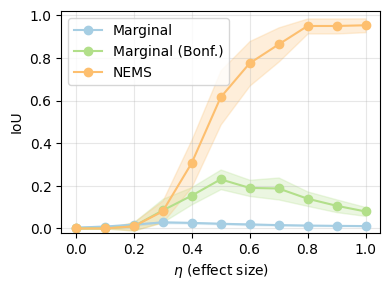

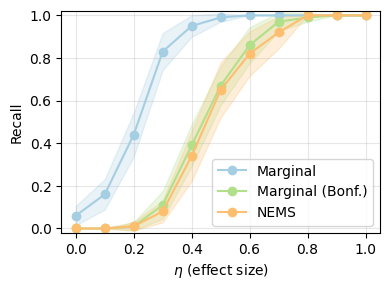

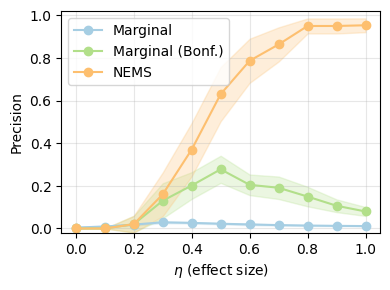

In [5]:
plot_iou_curve(
    summary_effect_iou,
    xcol="effect_scale",
    metric_name="IoU",
    x_label=r"$\eta$ (effect size)",
    out_path=f"results/{INTERACTION_FORM}/effect_size_IoU.pdf",
)
plot_iou_curve(
    summary_effect_recall,
    xcol="effect_scale",
    metric_name="Recall",
    x_label=r"$\eta$ (effect size)",
    out_path=f"results/{INTERACTION_FORM}/effect_size_recall.pdf",
)
plot_iou_curve(
    summary_effect_precision,
    xcol="effect_scale",
    metric_name="Precision",
    x_label=r"$\eta$ (effect size)",
    out_path=f"results/{INTERACTION_FORM}/effect_size_precision.pdf",
)
plt.show()


## Sweep 2 — sample size vs IoU

In [6]:
N_GRID = np.linspace(100, 1000, 10)
EFFECT_FIXED = 0.8

df_n = run_sweep_n(N_GRID, effect_fixed=EFFECT_FIXED, **DGP_KWARGS)
summary_n_iou = summarize_curve(df_n, xcol="n", ycol="iou")
summary_n_recall = summarize_curve(df_n, xcol="n", ycol="recall")
summary_n_precision = summarize_curve(df_n, xcol="n", ycol="precision")

summary_n_iou


,n,method,mean,std,count,se
0,100,Marginal,0.030421,0.016740,50,0.002367
1,100,Marginal (Bonferroni),0.022857,0.081769,50,0.011564
2,100,NEMS,0.030000,0.119949,50,0.016963
3,200,Marginal,0.027092,0.010531,50,0.001489
4,200,Marginal (Bonferroni),0.136155,0.178517,50,0.025246
5,200,NEMS,0.303333,0.430801,50,0.060924
6,300,Marginal,0.021451,0.007107,50,0.001005
7,300,Marginal (Bonferroni),0.219947,0.179284,50,0.025355
8,300,NEMS,0.571667,0.482109,50,0.068181
9,400,Marginal,0.018355,0.004856,50,0.000687


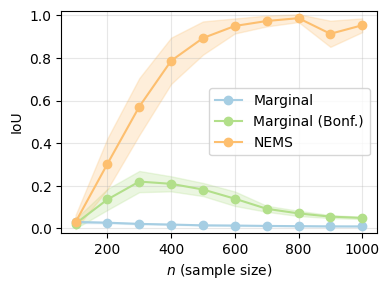

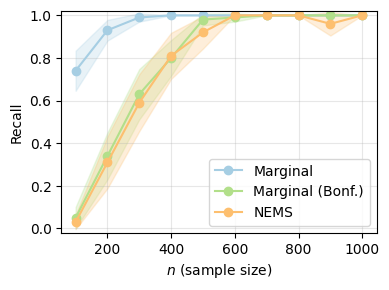

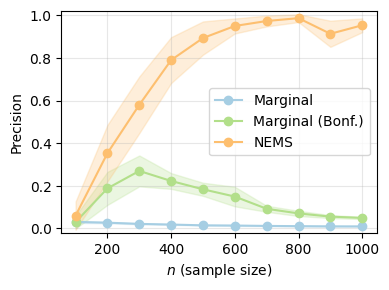

In [7]:
plot_iou_curve(
    summary_n_iou,
    xcol="n",
    metric_name="IoU",
    x_label=r"$n$ (sample size)",
    out_path=f"results/{INTERACTION_FORM}/sample_size_IoU.pdf",
)
plot_iou_curve(
    summary_n_recall,
    xcol="n",
    metric_name="Recall",
    x_label=r"$n$ (sample size)",
    out_path=f"results/{INTERACTION_FORM}/sample_size_recall.pdf",
)
plot_iou_curve(
    summary_n_precision,
    xcol="n",
    metric_name="Precision",
    x_label=r"$n$ (sample size)",
    out_path=f"results/{INTERACTION_FORM}/sample_size_precision.pdf",
)
plt.show()


## Optional diagnostics (selection counts, TP/FP)

In [8]:
diag_effect = (df_effect.groupby(["effect_scale", "method"])[["n_selected", "tp", "fp", "iou"]]
                  .mean()
                  .reset_index())
diag_n = (df_n.groupby(["n", "method"])[["n_selected", "tp", "fp", "iou"]]
          .mean()
          .reset_index())

display(diag_effect)
display(diag_n)


,effect_scale,method,n_selected,tp,fp,iou
0,0.0,Marginal,25.94,0.12,25.82,0.004063
1,0.0,Marginal (Bonferroni),0.06,0.00,0.06,0.000000
2,0.0,NEMS,0.06,0.00,0.06,0.000000
3,0.1,Marginal,29.86,0.32,29.54,0.008822
4,0.1,Marginal (Bonferroni),0.08,0.00,0.08,0.000000
5,0.1,NEMS,0.08,0.00,0.08,0.000000
6,0.2,Marginal,42.20,0.88,41.32,0.017781
7,0.2,Marginal (Bonferroni),0.20,0.02,0.18,0.010000
8,0.2,NEMS,0.18,0.02,0.16,0.010000
9,0.3,Marginal,60.62,1.66,58.96,0.028618


,n,method,n_selected,tp,fp,iou
0,100,Marginal,50.20,1.48,48.72,0.030421
1,100,Marginal (Bonferroni),0.82,0.10,0.72,0.022857
2,100,NEMS,0.42,0.06,0.36,0.030000
3,200,Marginal,78.16,1.86,76.30,0.027092
4,200,Marginal (Bonferroni),3.26,0.68,2.58,0.136155
5,200,NEMS,1.00,0.62,0.38,0.303333
6,300,Marginal,102.20,1.98,100.22,0.021451
7,300,Marginal (Bonferroni),5.70,1.26,4.44,0.219947
8,300,NEMS,1.54,1.18,0.36,0.571667
9,400,Marginal,116.12,2.00,114.12,0.018355


### Notes
- `Marginal (raw)` = one-shot marginal interaction tests with threshold `alpha`
- `Marginal (Bonf.)` = one-shot marginal interaction tests with threshold `alpha / m`
- `NEMS` = recursive conditional testing with Bonferroni gate over remaining coordinates
- Ground truth is **exactly** the two principally aligned neurons (`PRINCIPAL_IDX`), as requested.
- To stress-test nonlinearity, switch `INTERACTION_FORM = "quadratic"`.
- To match the paper's logistic example, switch `OUTCOME_FAMILY = "binary"` (expect noisier curves).
